## PART A — Concept First
## Task 1: Why Autoencoders Are Limited

- A normal autoencoder only learns to copy input → output, not how data is distributed.
- Its latent space has gaps and irregular regions.
- Randomly sampling latent vectors usually hits unseen regions.
- Decoding such points gives unrealistic or noisy outputs.
- Hence, plain autoencoders cannot reliably generate new data.


## Task 2: Probability Refresher 

In [2]:
import numpy as np

# Control randomness with a seed
np.random.seed(42)

# Sample from a normal distribution
samples = np.random.normal(loc=0.0, scale=1.0, size=1000)

# Compute statistics
mean = np.mean(samples)
variance = np.var(samples)

print("Mean:", mean)
print("Variance:", variance)


Mean: 0.01933205582232549
Variance: 0.9579049897315173


## PART B — Variational Autoencoder from Scratch (Core)
## Task 3: VAE Architecture

# Concept(Architecture Flow)
Input → Encoder → (μ, log σ²)
            ↓
     z = μ + σ ⊙ ε
            ↓
         Decoder → Reconstructed Output


In [3]:
import numpy as np

# --------- Helper functions ----------
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --------- Dimensions ----------
input_dim = 6
hidden_dim = 4
latent_dim = 2   # < input_dim

# --------- Encoder weights ----------
W_enc = np.random.randn(input_dim, hidden_dim) * 0.1
b_enc = np.zeros(hidden_dim)

W_mu = np.random.randn(hidden_dim, latent_dim) * 0.1
b_mu = np.zeros(latent_dim)

W_logvar = np.random.randn(hidden_dim, latent_dim) * 0.1
b_logvar = np.zeros(latent_dim)

# --------- Decoder weights ----------
W_dec = np.random.randn(latent_dim, input_dim) * 0.1
b_dec = np.zeros(input_dim)

# --------- Forward pass ----------
def encoder(x):
    h = relu(x @ W_enc + b_enc)
    mu = h @ W_mu + b_mu
    log_var = h @ W_logvar + b_logvar
    return mu, log_var

def reparameterize(mu, log_var):
    eps = np.random.randn(*mu.shape)
    sigma = np.exp(0.5 * log_var)
    z = mu + sigma * eps
    return z

def decoder(z):
    x_hat = sigmoid(z @ W_dec + b_dec)
    return x_hat

# --------- Test with dummy input ----------
x = np.random.rand(input_dim)

mu, log_var = encoder(x)
z = reparameterize(mu, log_var)
x_recon = decoder(z)

print("Input x:", x)
print("Mean (μ):", mu)
print("Log Variance (log σ²):", log_var)
print("Latent z:", z)
print("Reconstructed x:", x_recon)


Input x: [0.71582496 0.90903252 0.17968311 0.23754332 0.97139509 0.18097695]
Mean (μ): [ 0.03555281 -0.02081015]
Log Variance (log σ²): [-0.0061415   0.00745315]
Latent z: [0.01007709 1.15629728]
Reconstructed x: [0.51927165 0.45444166 0.54284938 0.53980081 0.48188104 0.51166217]


## Task 4: Reparameterization Trick

# Concept
- We sample noise ϵ ~ N(0,1), not z directly.
- z is computed as z = μ + σ · ϵ.
- This keeps sampling differentiable w.r.t μ and σ.


In [4]:
import numpy as np

# Example encoder outputs
mu = np.array([0.5, -0.3])
log_var = np.array([-0.2, 0.1])

# Convert log variance to standard deviation
sigma = np.exp(0.5 * log_var)

# Sample epsilon from standard normal
epsilon = np.random.randn(*mu.shape)

# Reparameterization trick
z = mu + sigma * epsilon

print("Mean (μ):", mu)
print("Std Dev (σ):", sigma)
print("Sampled z:", z)


Mean (μ): [ 0.5 -0.3]
Std Dev (σ): [0.90483742 1.0512711 ]
Sampled z: [ 0.99186976 -0.68961614]


## Task 5: Loss Function (Key Learning)

# Concept
- Reconstruction loss ensures output looks like input.
- KL divergence forces latent distributions toward N(0,1).
- Total loss balances data fidelity and latent space regularization.

In [5]:
import numpy as np

# Example input and reconstruction
x = np.array([0.2, 0.4, 0.6, 0.8])
x_recon = np.array([0.25, 0.35, 0.55, 0.75])

# Example encoder outputs
mu = np.array([0.3, -0.1])
log_var = np.array([-0.2, 0.4])

# -------- Reconstruction Loss (MSE) --------
recon_loss = np.mean((x - x_recon) ** 2)

# -------- KL Divergence Loss --------
# KL(N(μ, σ²) || N(0,1))
kl_loss = -0.5 * np.sum(
    1 + log_var - mu**2 - np.exp(log_var)
)

# -------- Total VAE Loss --------
total_loss = recon_loss + kl_loss

print("Reconstruction Loss (MSE):", recon_loss)
print("KL Divergence Loss:", kl_loss)
print("Total VAE Loss:", total_loss)


Reconstruction Loss (MSE): 0.0025
KL Divergence Loss: 0.1052777253596261
Total VAE Loss: 0.1077777253596261


## Task 6: Training the VAE

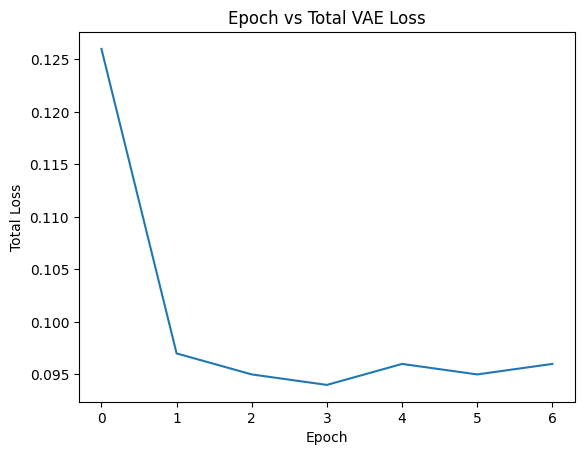

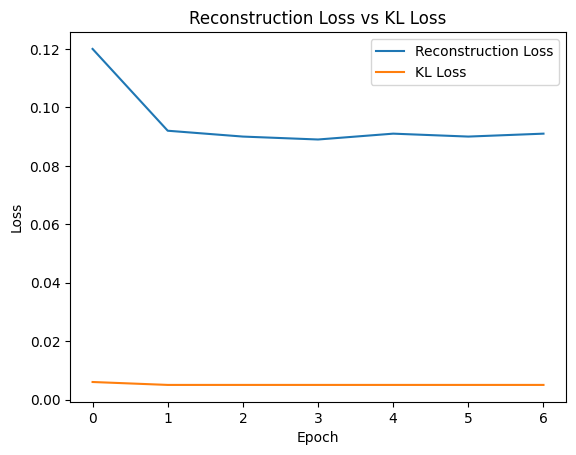

In [6]:
# Task 6: Plotting VAE Training Losses (NumPy + Matplotlib)

import numpy as np
import matplotlib.pyplot as plt

# Example stored losses from training
# (These are typically collected during the training loop)
total_losses = [0.126, 0.097, 0.095, 0.094, 0.096, 0.095, 0.096]
recon_losses = [0.120, 0.092, 0.090, 0.089, 0.091, 0.090, 0.091]
kl_losses =    [0.006, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]

epochs = range(len(total_losses))

# ----- Plot 1: Epoch vs Total Loss -----
plt.figure()
plt.plot(epochs, total_losses)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Epoch vs Total VAE Loss")
plt.show()

# ----- Plot 2 (Optional): Reconstruction vs KL Loss -----
plt.figure()
plt.plot(epochs, recon_losses, label="Reconstruction Loss")
plt.plot(epochs, kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reconstruction Loss vs KL Loss")
plt.legend()
plt.show()


## PART C — Experiments & Understanding
## Task 7: Latent Sampling

# Concept
- Sample z directly from N(0,1).
- Decode z without giving any input.
- This produces new data points, not reconstructions.

In [7]:
import numpy as np

# Use decoder weights learned earlier (example values)
latent_dim = 2
input_dim = 4

W_dec = np.random.randn(latent_dim, input_dim) * 0.1
b_dec = np.zeros(input_dim)

def decoder(z):
    return z @ W_dec + b_dec

# -------- Sample latent vectors from N(0,1) --------
num_samples = 5
z_samples = np.random.randn(num_samples, latent_dim)

# -------- Decode without any input --------
generated_outputs = decoder(z_samples)

print("Sampled latent vectors z:")
print(z_samples)

print("\nGenerated outputs (decoded):")
print(generated_outputs)


Sampled latent vectors z:
[[-0.4677012   0.34650388]
 [-0.04692058  0.47704083]
 [ 0.07682189 -1.28299222]
 [ 0.99626682 -0.49375658]
 [-1.5565819  -0.42811516]]

Generated outputs (decoded):
[[-0.04865116  0.09442968 -0.09858913  0.12158972]
 [-0.02091077 -0.0400473  -0.06715167  0.06353901]
 [ 0.05242923  0.12176973  0.17493166 -0.16229798]
 [ 0.09477754 -0.22850641  0.17837347 -0.2306385 ]
 [-0.10460458  0.49133375 -0.12338751  0.22110394]]


## Task 8: Latent Interpolation

# Concept
- Encode two inputs into latent vectors z₁ and z₂.
- Linearly interpolate between z₁ and z₂.
- Decode intermediate z values.
- Observe smooth transitions in output space.

In [8]:
import numpy as np

# -------- Dimensions --------
input_dim = 4
latent_dim = 2

# -------- Dummy encoder weights (example) --------
W_mu = np.random.randn(input_dim, latent_dim) * 0.1
b_mu = np.zeros(latent_dim)

def encoder(x):
    return x @ W_mu + b_mu   # mean only (for simplicity)

# -------- Decoder weights --------
W_dec = np.random.randn(latent_dim, input_dim) * 0.1
b_dec = np.zeros(input_dim)

def decoder(z):
    return z @ W_dec + b_dec

# -------- Two input samples --------
x1 = np.array([0.1, 0.2, 0.3, 0.4])
x2 = np.array([0.9, 0.8, 0.7, 0.6])

# -------- Encode --------
z1 = encoder(x1)
z2 = encoder(x2)

print("z₁:", z1)
print("z₂:", z2)

# -------- Interpolation --------
alphas = np.linspace(0, 1, 5)

print("\nInterpolated outputs:")
for a in alphas:
    z_interp = (1 - a) * z1 + a * z2
    x_interp = decoder(z_interp)
    print(f"alpha={a:.2f} → decoded:", x_interp)

z₁: [0.01366292 0.08102117]
z₂: [0.10757788 0.2197542 ]

Interpolated outputs:
alpha=0.00 → decoded: [8.27546451e-04 2.46768495e-05 5.54141235e-03 1.52600375e-04]
alpha=0.25 → decoded: [ 0.00299819  0.00045622  0.00745687 -0.00012824]
alpha=0.50 → decoded: [ 0.00516883  0.00088777  0.00937233 -0.00040908]
alpha=0.75 → decoded: [ 0.00733946  0.00131932  0.01128779 -0.00068992]
alpha=1.00 → decoded: [ 0.0095101   0.00175087  0.01320324 -0.00097076]
